In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(color_codes=True)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("C:\\Users\\HP\\online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,525461.000000,525461.000000,417534.000000
mean,10.337667,4.688834,15360.645478
std,107.424110,146.126914,1680.811316
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13983.000000
50%,3.000000,2.100000,15311.000000
75%,10.000000,4.210000,16799.000000
max,19152.000000,25111.090000,18287.000000


In [7]:
print("Total Duplicates:", df.duplicated().sum())

Total Duplicates: 6865


In [8]:
df.shape

(525461, 8)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(518596, 8)

In [11]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64


In [12]:
df_seg = df.copy()

In [13]:
df.dropna(subset=['Description'], inplace=True)
df_seg.dropna(subset=['Customer ID'], inplace=True)

In [14]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [15]:
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df_seg = df_seg[(df_seg['Quantity'] > 0) & (df_seg['Price'] > 0)]

In [16]:
df['Quantity'].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [17]:
df_eda = df[df['Quantity'] < 1000].copy()

In [18]:
df['TotalSales'] = df['Quantity'] * df['Price']
df_eda['TotalSales'] = df_eda['Quantity'] * df_eda['Price']
df_seg['TotalSales'] = df_seg['Quantity'] * df_seg['Price']

In [19]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')  
monthly_sales = df.groupby('Month')['TotalSales'].sum().reset_index()
print(monthly_sales)

      Month   TotalSales
0   2009-12   822483.950
1   2010-01   651155.112
2   2010-02   551878.296
3   2010-03   830915.261
4   2010-04   678875.252
5   2010-05   657705.500
6   2010-06   749537.310
7   2010-07   648810.270
8   2010-08   695251.910
9   2010-09   921696.991
10  2010-10  1161902.220
11  2010-11  1464293.142
12  2010-12   437631.020


In [20]:
daily_sales = df.groupby('InvoiceDate')['TotalSales'].sum().reset_index()
print(daily_sales)

              InvoiceDate  TotalSales
0     2009-12-01 07:45:00      505.30
1     2009-12-01 07:46:00      145.80
2     2009-12-01 09:06:00      630.33
3     2009-12-01 09:08:00      310.75
4     2009-12-01 09:24:00     2286.24
...                   ...         ...
19463 2010-12-09 18:58:00      298.95
19464 2010-12-09 19:23:00      310.45
19465 2010-12-09 19:28:00       93.45
19466 2010-12-09 19:32:00      317.59
19467 2010-12-09 20:01:00      300.64

[19468 rows x 2 columns]


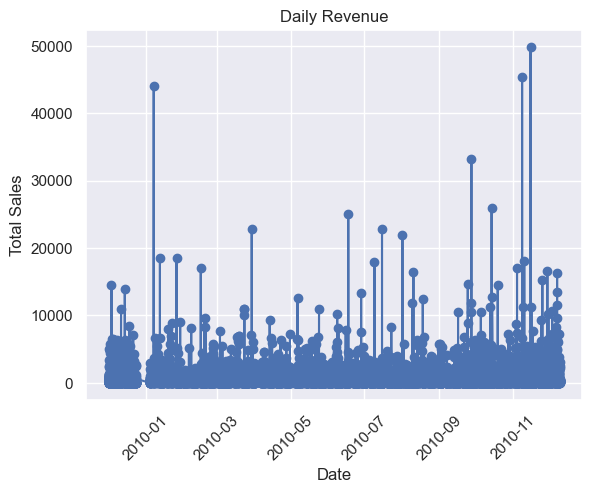

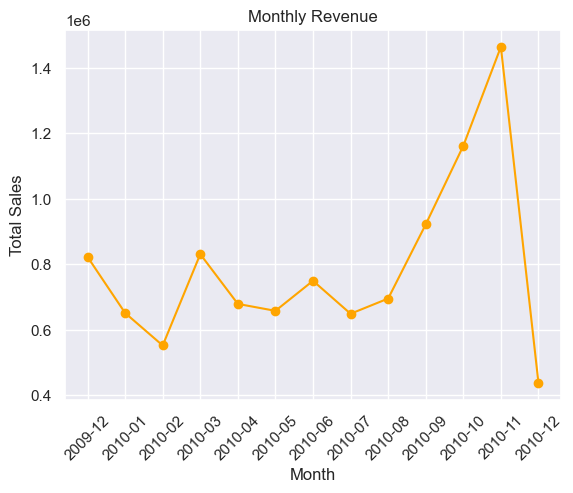

<Figure size 1200x800 with 0 Axes>

In [21]:
#Daily Revenue
plt.plot(daily_sales['InvoiceDate'], daily_sales['TotalSales'], marker='o')
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()
#Monthly Revenue
plt.plot(monthly_sales['Month'].astype(str), monthly_sales['TotalSales'], marker='o', color='orange')
plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.figure(figsize=(12,8))
plt.show()

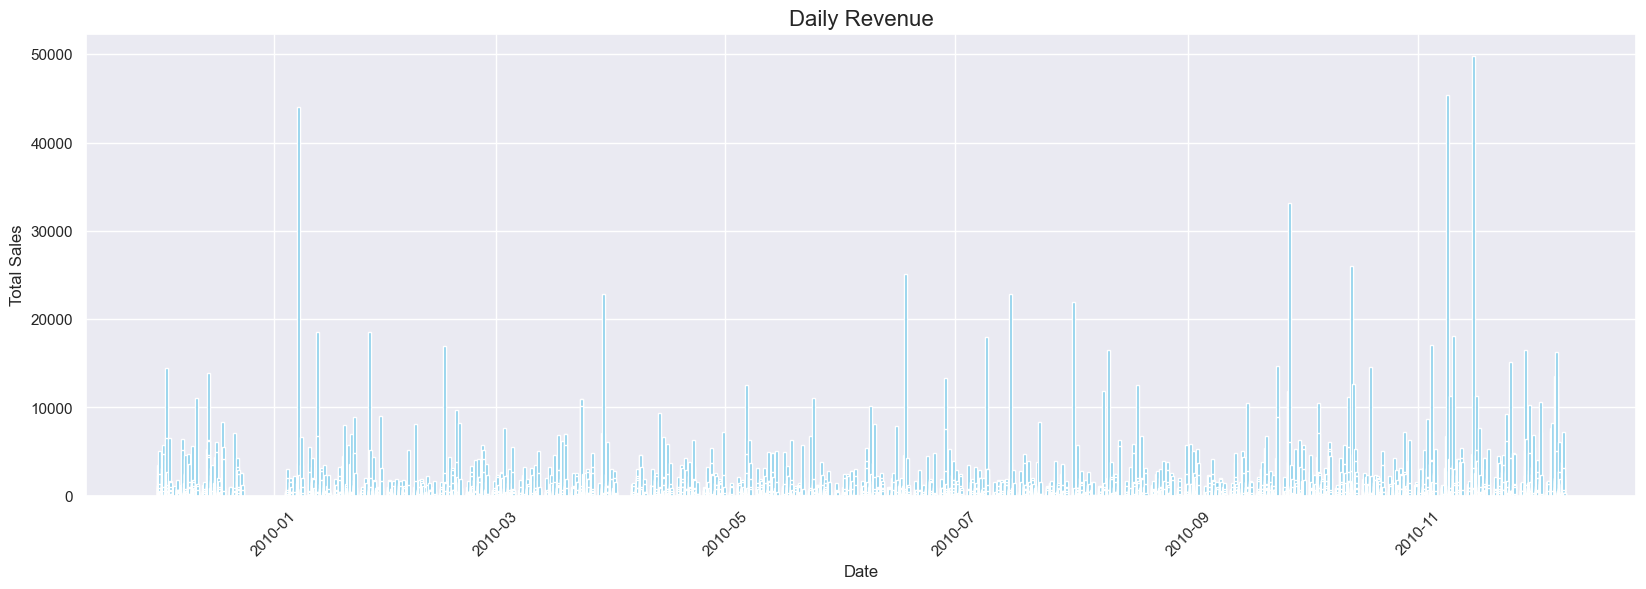

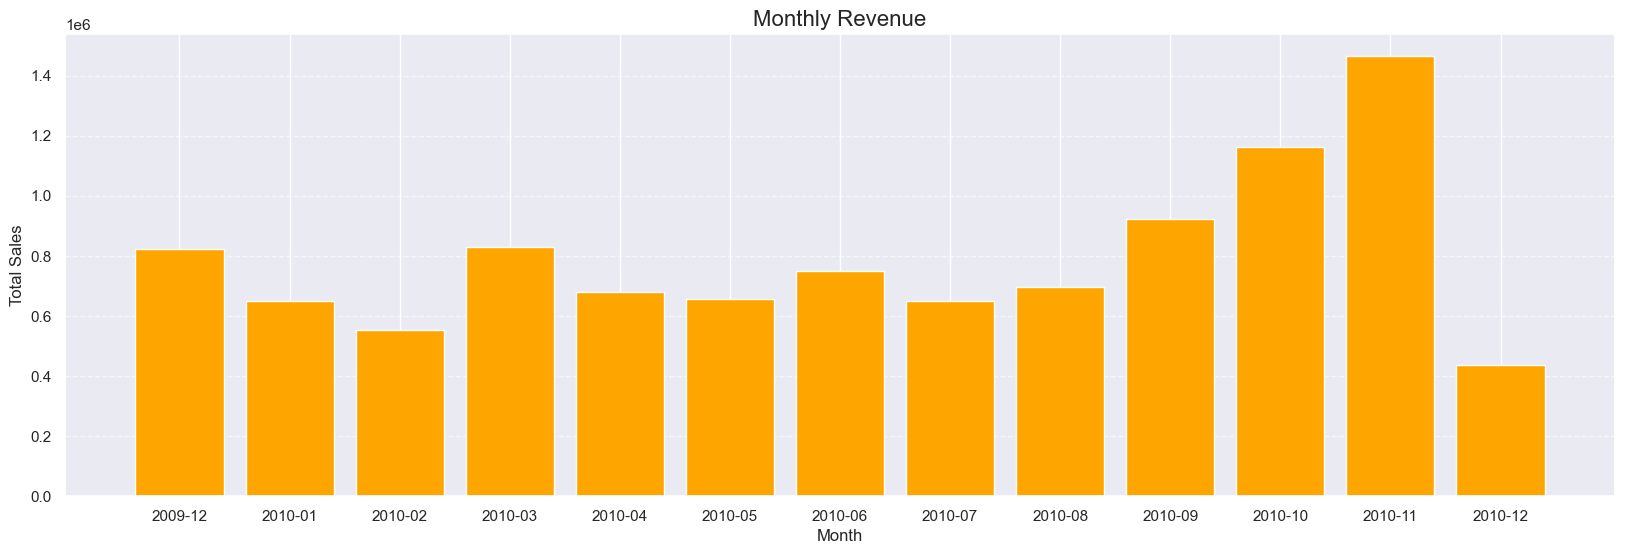

In [22]:
#Daily Revenue
plt.figure(figsize=(20,6))  # wider plot
plt.bar(daily_sales['InvoiceDate'], daily_sales['TotalSales'], color="skyblue")
plt.title("Daily Revenue", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)
plt.show()
#Monthly Revenue
plt.figure(figsize=(20,6))
plt.bar(monthly_sales['Month'].astype(str), monthly_sales['TotalSales'], color="orange")
plt.title("Monthly Revenue", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [23]:
#unique customers
unique_customers= df['Customer ID'].nunique()
print("Unique Customers:", unique_customers)
#Revenue per customer
customer_revenue=df.groupby('Customer ID')['TotalSales'].sum().reset_index()
customer_revenue = customer_revenue.sort_values(by='TotalSales', ascending=False)
#Pareto Principle
total_revenue = customer_revenue['TotalSales'].sum()
customer_revenue['RevenueShare'] = customer_revenue['TotalSales'] / total_revenue
customer_revenue['CumShare'] = customer_revenue['RevenueShare'].cumsum()
top_20_customers = customer_revenue.iloc[:int(0.2*len(customer_revenue))]
pareto_revenue_share = top_20_customers['TotalSales'].sum() / total_revenue
print("Top 20% customers contribute:", round(pareto_revenue_share*100, 2), "% of revenue")
#Average Order Value
aov = df['TotalSales'].sum() / df['Invoice'].nunique()
print("Average Order Value (AOV):", round(aov, 2))
#Orders per Customer
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
orders_per_customer.rename(columns={'Invoice':'OrdersCount'}, inplace=True)

Unique Customers: 4312
Top 20% customers contribute: 73.53 % of revenue
Average Order Value (AOV): 490.27


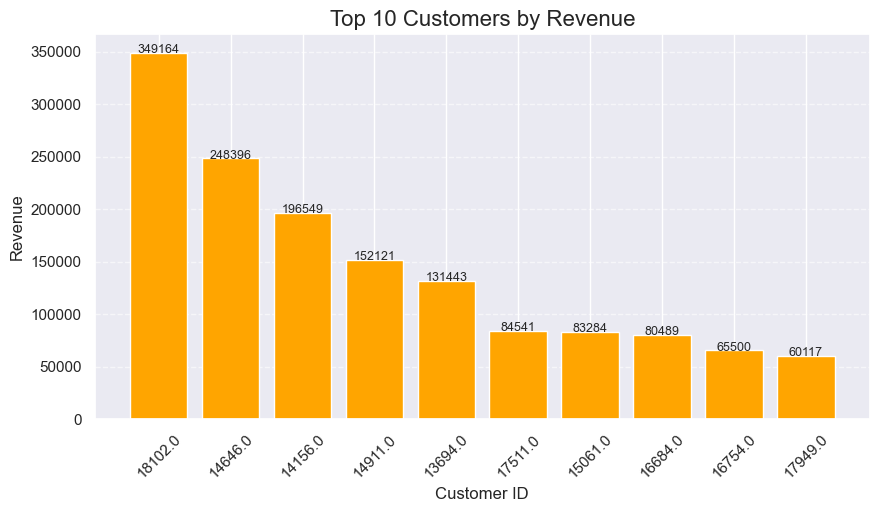

In [24]:
top10 = customer_revenue.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10['Customer ID'].astype(str), top10['TotalSales'], color="orange")
plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add value labels
for i, v in enumerate(top10['TotalSales']):
    plt.text(i, v+5, str(int(v)), ha='center', fontsize=9)

plt.savefig("Images/Customer_revenue.png")
plt.show()

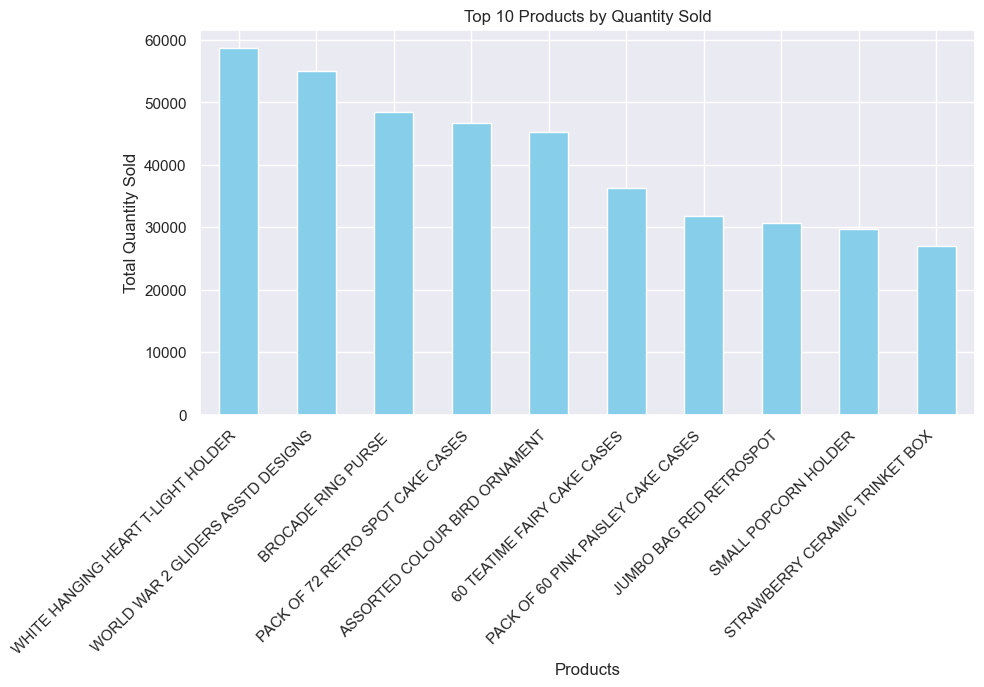

In [41]:
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products_qty.plot(kind='bar',figsize=(10,5), color="skyblue")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Products")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")
plt.savefig("images/product_distribution.png")
plt.show()

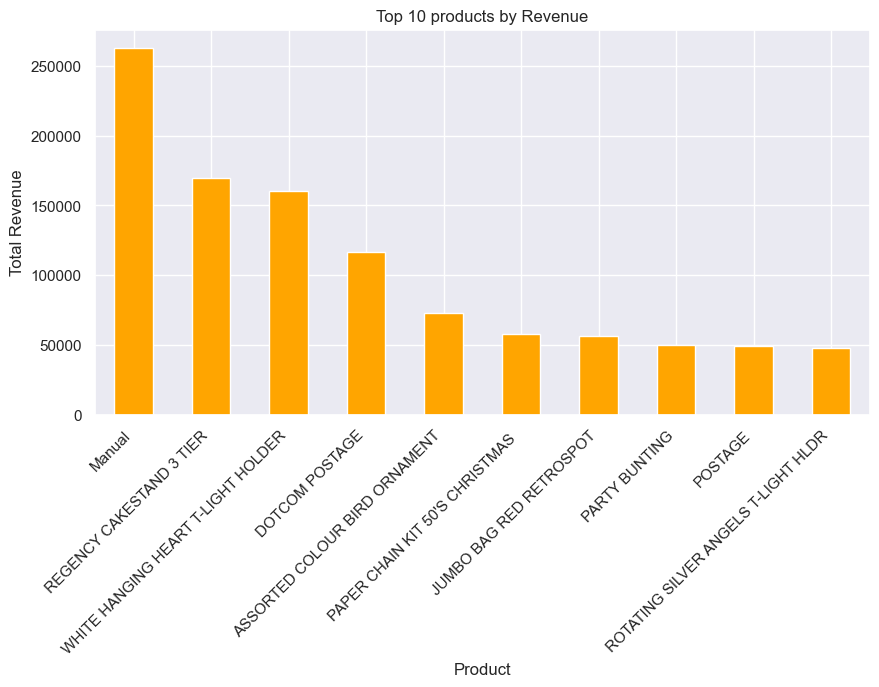

In [26]:
top_products_revenue= (df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(10))
top_products_revenue.plot(kind='bar',figsize=(10,5), color="orange")
plt.title("Top 10 products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

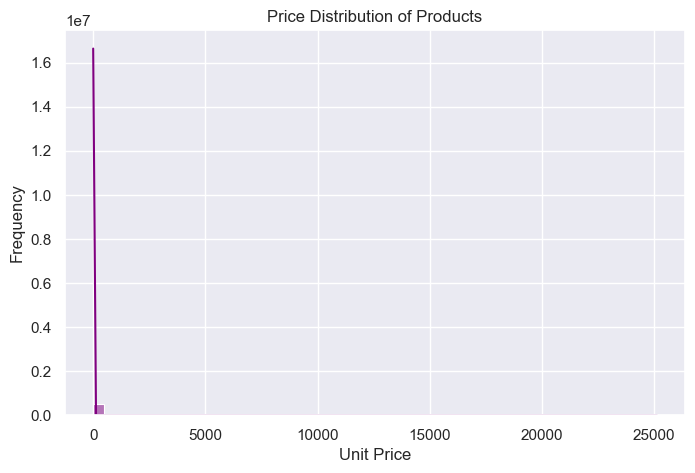

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True, color="purple")
plt.title("Price Distribution of Products")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

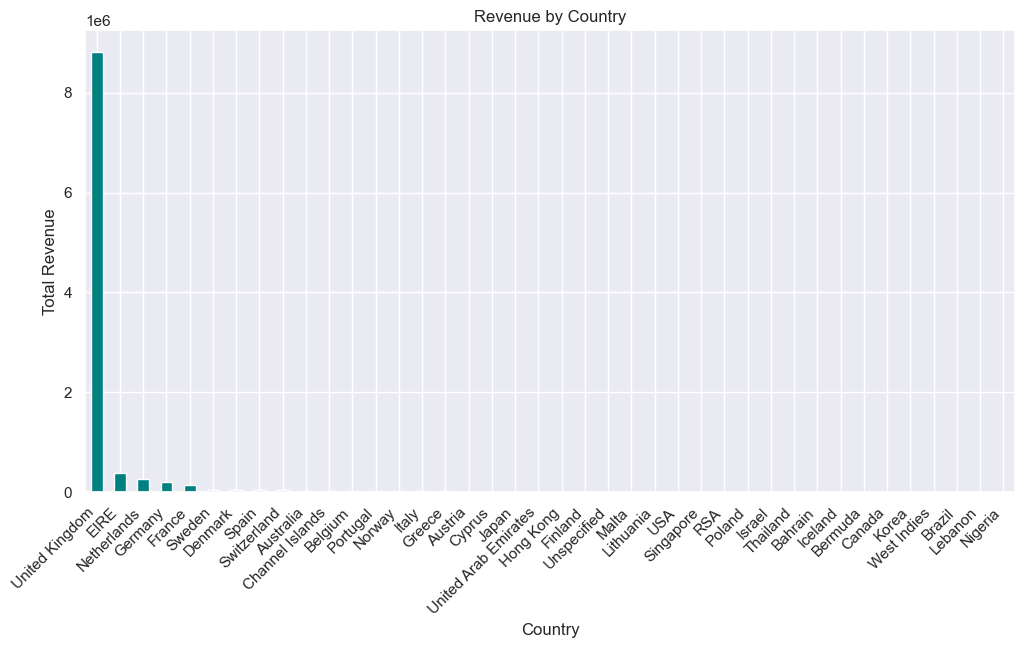

In [28]:
revenue_by_country = (
    df.groupby('Country')['TotalSales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
revenue_by_country.plot(kind='bar', color="teal")
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

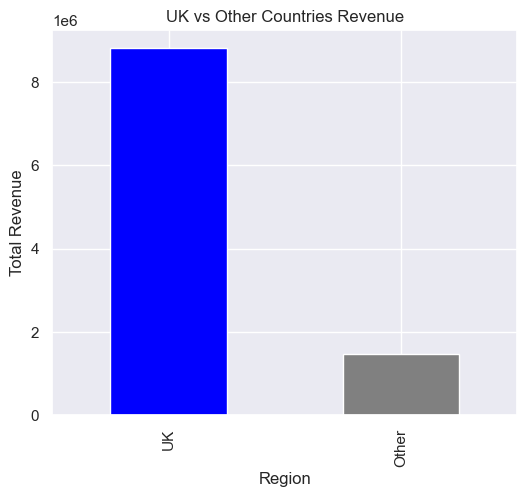

In [42]:
df['Region'] = df['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'Other')

uk_vs_other = (
    df.groupby('Region')['TotalSales']
      .sum()
      .sort_values(ascending=False)
)

uk_vs_other.plot(kind='bar', figsize=(6,5), color=["blue", "gray"])
plt.title("UK vs Other Countries Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.savefig("images/Uk_vs_other.png")
plt.show()


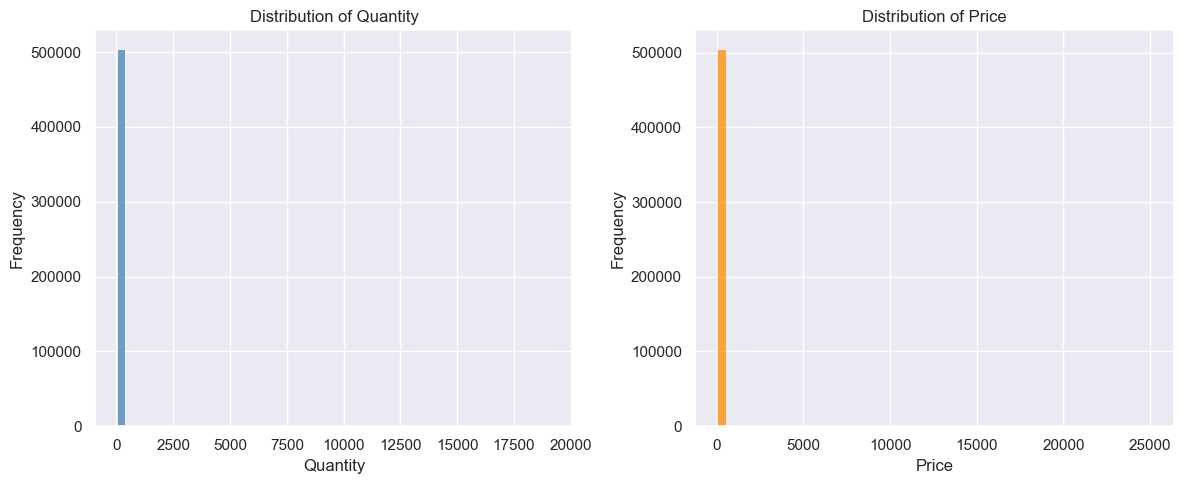

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Quantity'], bins=50, kde=False, color="steelblue")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.histplot(df['Price'], bins=50, kde=False, color="darkorange")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("images/price_qty_distribution.png")
plt.show()


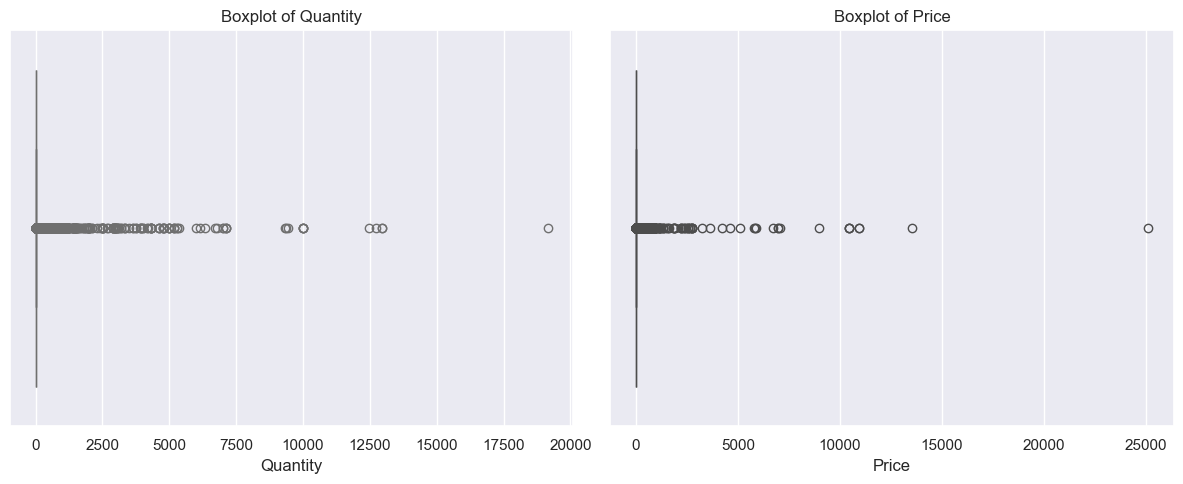

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'], color="skyblue")
plt.title("Boxplot of Quantity")

plt.subplot(1,2,2)
sns.boxplot(x=df['Price'], color="orange")
plt.title("Boxplot of Price")

plt.tight_layout()
plt.show()


In [32]:
import datetime as dt


ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                               # Frequency (unique invoices)
    'TotalSales': 'sum'                                   # Monetary
}).reset_index()


rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSales': 'Monetary'
}, inplace=True)

rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [33]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,4312.0,15349.290353,1701.200176,12346.00,13882.5000,15350.500,16834.2500,18287.00
Recency,4312.0,91.171846,96.860633,1.00,18.0000,53.000,136.0000,374.00
Frequency,4312.0,4.455705,8.170213,1.00,1.0000,2.000,5.0000,205.00
Monetary,4312.0,2040.406712,8911.755977,2.95,307.1875,701.615,1714.9325,349164.35


In [34]:

rfm_for_clustering = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_for_clustering)


rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])


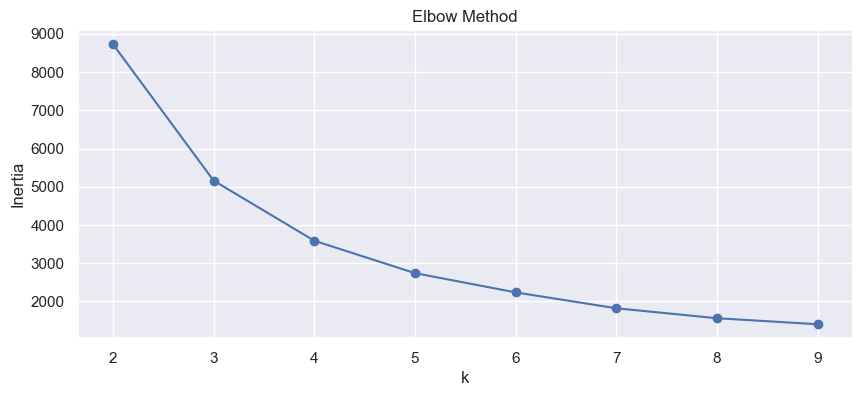

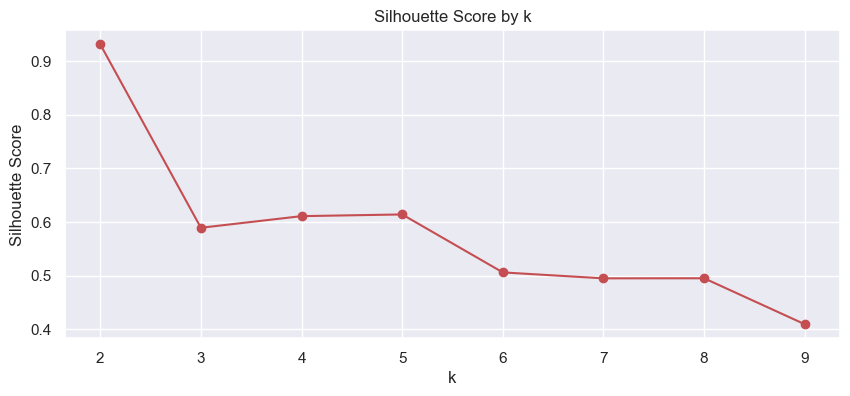

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

K = range(2,10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot Elbow
plt.figure(figsize=(10,4))
plt.plot(K, inertia, 'bo-')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.figure(figsize=(10,4))
plt.plot(K, silhouette, 'ro-')
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()


In [36]:
# Assume k=4 (based on elbow/silhouette)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.0,4.5,1710.7
1,243.0,1.7,593.5
2,5.6,113.6,215535.0
3,14.9,47.0,28896.4


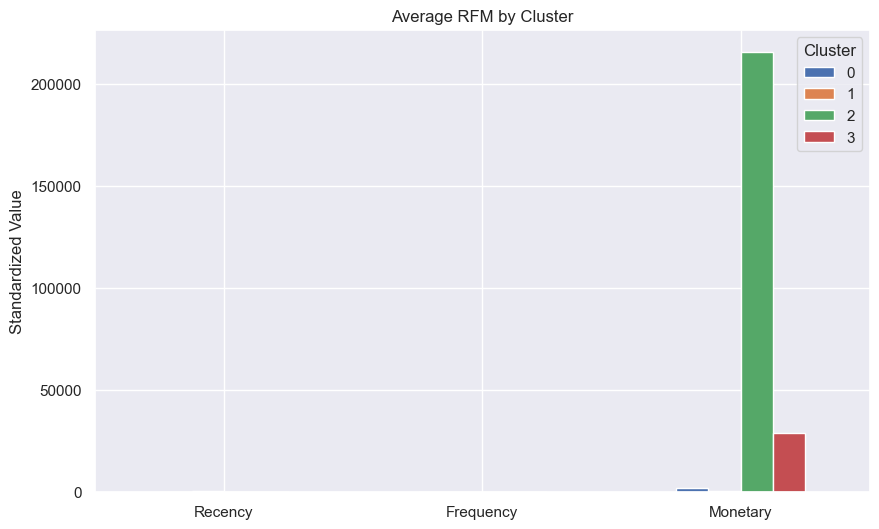

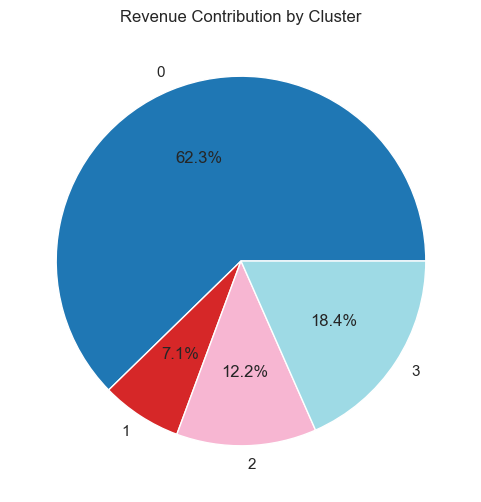

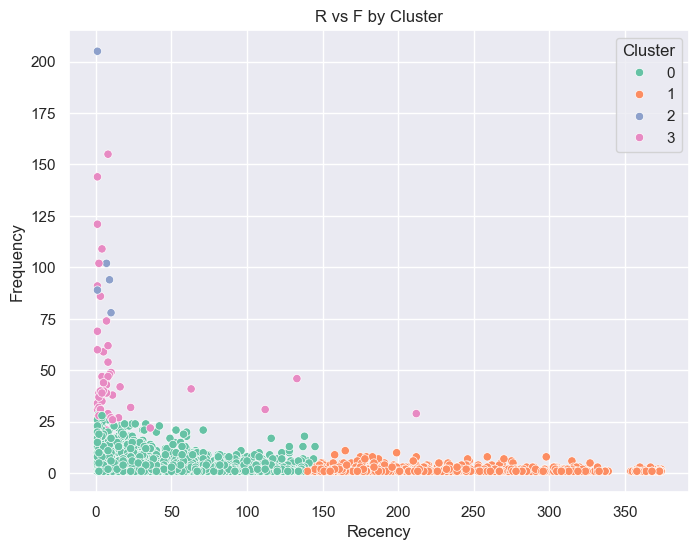

In [44]:
cluster_profile.T.plot(kind='bar', figsize=(10,6))
plt.title("Average RFM by Cluster")
plt.ylabel("Standardized Value")
plt.xticks(rotation=0)
plt.show()
rfm.groupby('Cluster')['Monetary'].sum().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6), colormap="tab20"
)
plt.title("Revenue Contribution by Cluster")
plt.ylabel("")
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set2')
plt.title("R vs F by Cluster")
plt.savefig("images/RFM_cluster.png")
plt.show()

In [38]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.0,4.5,1710.7
1,243.0,1.7,593.5
2,5.6,113.6,215535.0
3,14.9,47.0,28896.4


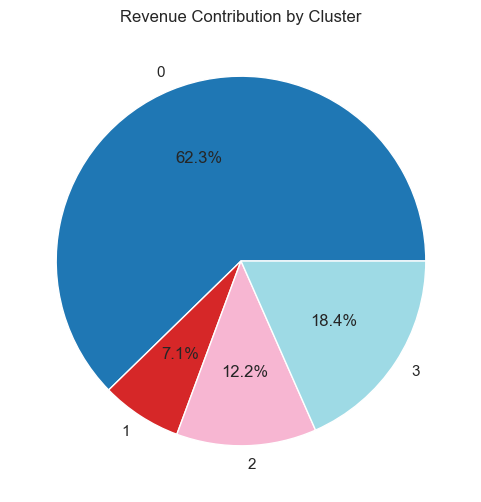

In [39]:
rfm.groupby('Cluster')['Monetary'].sum().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6), colormap="tab20"
)
plt.title("Revenue Contribution by Cluster")
plt.ylabel("")
plt.show()


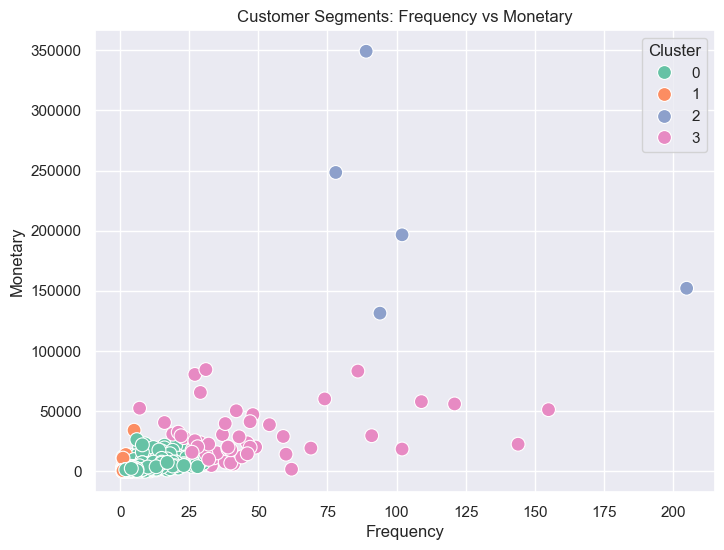

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', s=100)
plt.title("Customer Segments: Frequency vs Monetary")
plt.show()
